# EDA: Tasas de Graduación NY 2021

**Objetivo:** Predecir si un distrito escolar está en riesgo de baja graduación

| Elemento | Definición |
|----------|------------|
| Target | `en_riesgo` = 1 si graduación < 80% |
| Tipo | Clasificación binaria |
| Pregunta | ¿Este distrito necesita intervención? |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)


## 1. Carga de Datos


In [2]:
df = pd.read_csv('GRAD_RATE_AND_OUTCOMES_2021.csv', low_memory=False)
df.shape


(220304, 36)

In [3]:
df.head(3)


,report_school_year,aggregation_index,aggregation_type,aggregation_code,aggregation_name,lea_beds,lea_name,nrc_code,nrc_desc,county_code,...,reg_adv_cnt,reg_adv_pct,non_diploma_credential_cnt,non_diploma_credential_pct,still_enr_cnt,still_enr_pct,ged_cnt,ged_pct,dropout_cnt,dropout_pct
0,2020-21,0,Statewide,0,All Districts and Charters,NaN,NaN,NaN,NaN,NaN,...,70009,34%,2331,1%,4915,2%,1749,1%,16414,8%
1,2020-21,0,Statewide,0,All Districts and Charters,NaN,NaN,NaN,NaN,NaN,...,38169,38%,764,1%,1790,2%,728,1%,6163,6%
2,2020-21,0,Statewide,0,All Districts and Charters,NaN,NaN,NaN,NaN,NaN,...,31840,30%,1567,1%,3125,3%,1021,1%,10251,10%


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220304 entries, 0 to 220303
Data columns (total 36 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   report_school_year          220304 non-null  object 
 1   aggregation_index           220304 non-null  int64  
 2   aggregation_type            220304 non-null  object 
 3   aggregation_code            220304 non-null  int64  
 4   aggregation_name            220254 non-null  object 
 5   lea_beds                    130282 non-null  float64
 6   lea_name                    130282 non-null  object 
 7   nrc_code                    212252 non-null  float64
 8   nrc_desc                    212252 non-null  object 
 9   county_code                 219218 non-null  float64
 10  county_name                 219218 non-null  object 
 11  nyc_ind                     219218 non-null  float64
 12  boces_code                  211304 non-null  float64
 13  boces_name    

## 2. Valores Faltantes

Los NaN son por diseño: `lea_name` es NaN en datos Statewide/County porque no aplica a ese nivel de agregación.


In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
pd.DataFrame({'Faltantes': missing, '%': missing_pct.round(1)})[missing > 0].sort_values('%', ascending=False)


,Faltantes,%
lea_beds,90022,40.9
lea_name,90022,40.9
boces_code,9000,4.1
boces_name,9000,4.1
nrc_code,8052,3.7
nrc_desc,8052,3.7
county_code,1086,0.5
county_name,1086,0.5
nyc_ind,1086,0.5
aggregation_name,50,0.0


In [6]:
df['aggregation_type'].value_counts()


aggregation_type
School                    138778
District                   72526
County                      7914
Need/Resource Category       948
Statewide                    138
Name: count, dtype: int64

## 3. Limpieza de Datos

Filtramos solo **Distritos** y subgrupo **All Students** para evitar duplicados.


In [7]:
df['grad_pct_clean'] = pd.to_numeric(df['grad_pct'].str.replace('%', ''), errors='coerce')
df['dropout_pct_clean'] = pd.to_numeric(df['dropout_pct'].str.replace('%', ''), errors='coerce')
df['local_pct_clean'] = pd.to_numeric(df['local_pct'].str.replace('%', ''), errors='coerce')
df['reg_adv_pct_clean'] = pd.to_numeric(df['reg_adv_pct'].str.replace('%', ''), errors='coerce')
df['still_enr_pct_clean'] = pd.to_numeric(df['still_enr_pct'].str.replace('%', ''), errors='coerce')

df_clean = df[(df['aggregation_type'] == 'District') & (df['subgroup_name'] == 'All Students')].copy()
df_clean = df_clean.dropna(subset=['grad_pct_clean'])

f"Registros limpios: {len(df_clean):,}"


'Registros limpios: 4,040'

## 4. Análisis del Target


In [8]:
df_clean['grad_pct_clean'].describe()


count    4040.000000
mean       88.721287
std        11.385806
min         0.000000
25%        86.000000
50%        91.000000
75%        95.000000
max       100.000000
Name: grad_pct_clean, dtype: float64

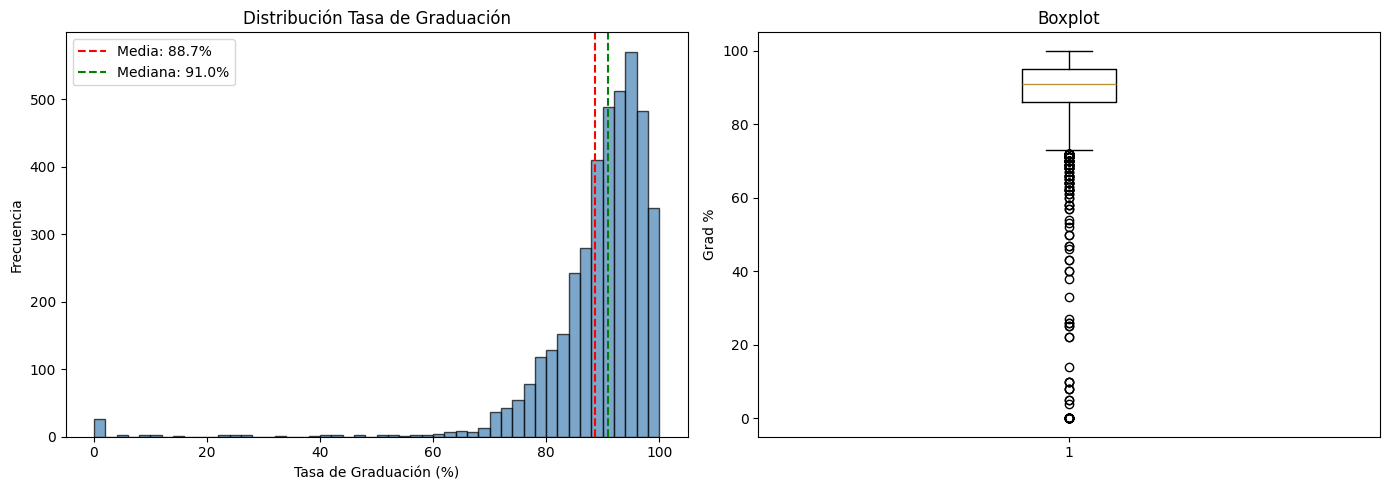

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['grad_pct_clean'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df_clean['grad_pct_clean'].mean(), color='red', linestyle='--', label=f"Media: {df_clean['grad_pct_clean'].mean():.1f}%")
axes[0].axvline(df_clean['grad_pct_clean'].median(), color='green', linestyle='--', label=f"Mediana: {df_clean['grad_pct_clean'].median():.1f}%")
axes[0].set_xlabel('Tasa de Graduación (%)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución Tasa de Graduación')
axes[0].legend()

axes[1].boxplot(df_clean['grad_pct_clean'].dropna())
axes[1].set_ylabel('Grad %')
axes[1].set_title('Boxplot')

plt.tight_layout()
plt.show()


## 5. Detección de Outliers (IQR)


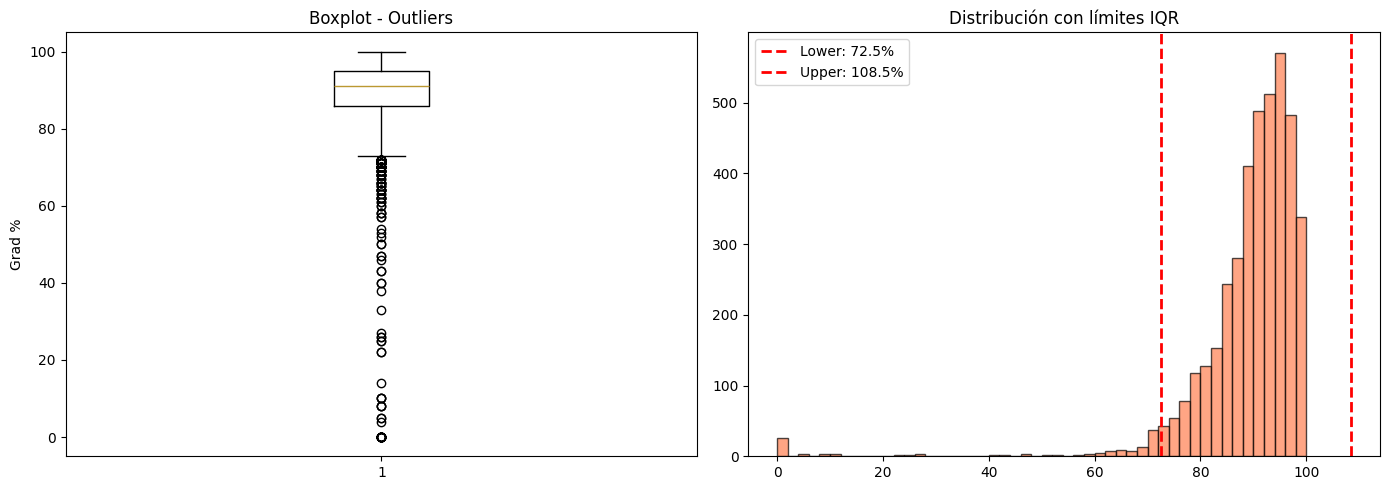

,Q1,Q3,IQR,Lower,Upper,Outliers,% Outliers
0,86.0,95.0,9.0,72.5,108.5,163,4.0%


In [10]:
Q1 = df_clean['grad_pct_clean'].quantile(0.25)
Q3 = df_clean['grad_pct_clean'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['grad_pct_clean'] < lower) | (df_clean['grad_pct_clean'] > upper)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df_clean['grad_pct_clean'])
axes[0].set_title('Boxplot - Outliers')
axes[0].set_ylabel('Grad %')

axes[1].hist(df_clean['grad_pct_clean'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(lower, color='red', linestyle='--', linewidth=2, label=f'Lower: {lower:.1f}%')
axes[1].axvline(upper, color='red', linestyle='--', linewidth=2, label=f'Upper: {upper:.1f}%')
axes[1].set_title('Distribución con límites IQR')
axes[1].legend()

plt.tight_layout()
plt.show()

pd.DataFrame({
    'Q1': [Q1], 'Q3': [Q3], 'IQR': [IQR], 
    'Lower': [lower], 'Upper': [upper],
    'Outliers': [len(outliers)], '% Outliers': [f"{len(outliers)/len(df_clean)*100:.1f}%"]
})


## 6. Definición del Target Binario

Umbral de **80%**: distritos por debajo se consideran "en riesgo".


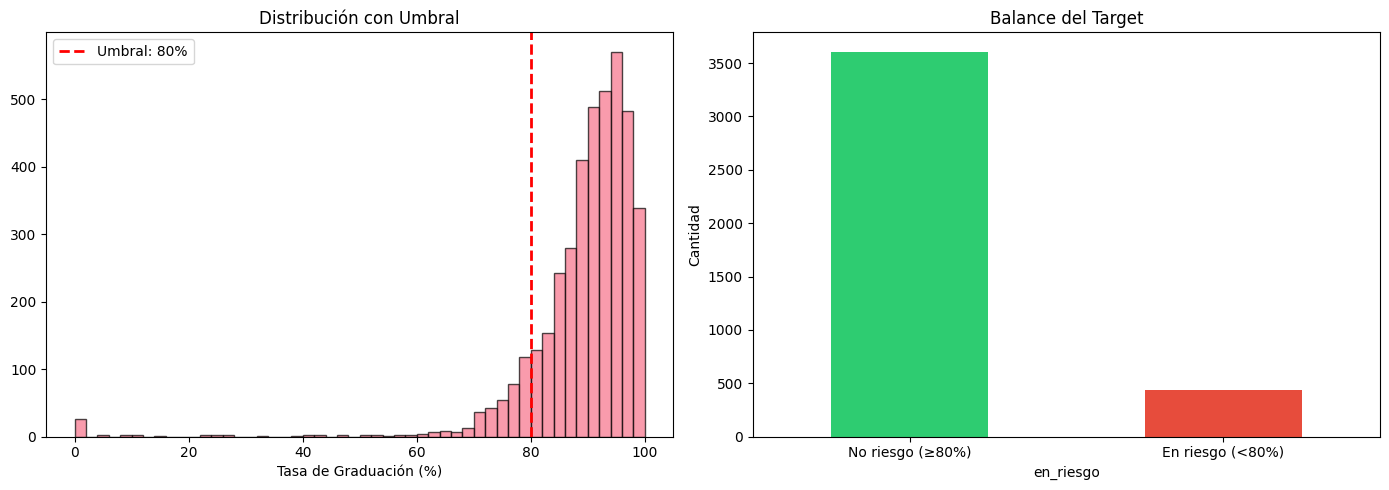

,Clase,Cantidad,%
0,No riesgo (≥80%),3608,89.3%
1,En riesgo (<80%),432,10.7%


In [11]:
df_clean['en_riesgo'] = (df_clean['grad_pct_clean'] < 80).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['grad_pct_clean'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(80, color='red', linestyle='--', linewidth=2, label='Umbral: 80%')
axes[0].set_xlabel('Tasa de Graduación (%)')
axes[0].set_title('Distribución con Umbral')
axes[0].legend()

colors = ['#2ecc71', '#e74c3c']
df_clean['en_riesgo'].value_counts().plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_xticklabels(['No riesgo (≥80%)', 'En riesgo (<80%)'], rotation=0)
axes[1].set_ylabel('Cantidad')
axes[1].set_title('Balance del Target')

plt.tight_layout()
plt.show()

pd.DataFrame({
    'Clase': ['No riesgo (≥80%)', 'En riesgo (<80%)'],
    'Cantidad': df_clean['en_riesgo'].value_counts().values,
    '%': [f"{(1-df_clean['en_riesgo'].mean())*100:.1f}%", f"{df_clean['en_riesgo'].mean()*100:.1f}%"]
})


## 7. Correlación de Features con Target


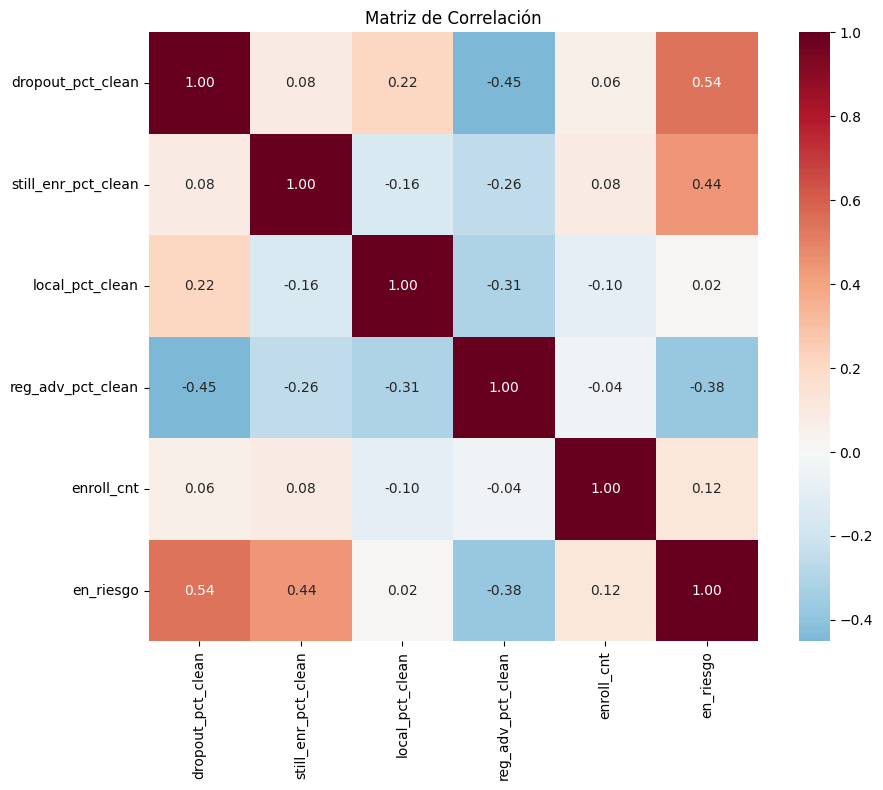

In [12]:
features_corr = ['dropout_pct_clean', 'still_enr_pct_clean', 'local_pct_clean', 
                 'reg_adv_pct_clean', 'enroll_cnt', 'en_riesgo']

corr_matrix = df_clean[features_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', square=True)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()


In [13]:
corr_matrix['en_riesgo'].drop('en_riesgo').sort_values(ascending=False).to_frame('Correlación con Target')


,Correlación con Target
dropout_pct_clean,0.538962
still_enr_pct_clean,0.441340
enroll_cnt,0.119775
local_pct_clean,0.017214
reg_adv_pct_clean,-0.382838


## 8. Features Numéricas vs Target


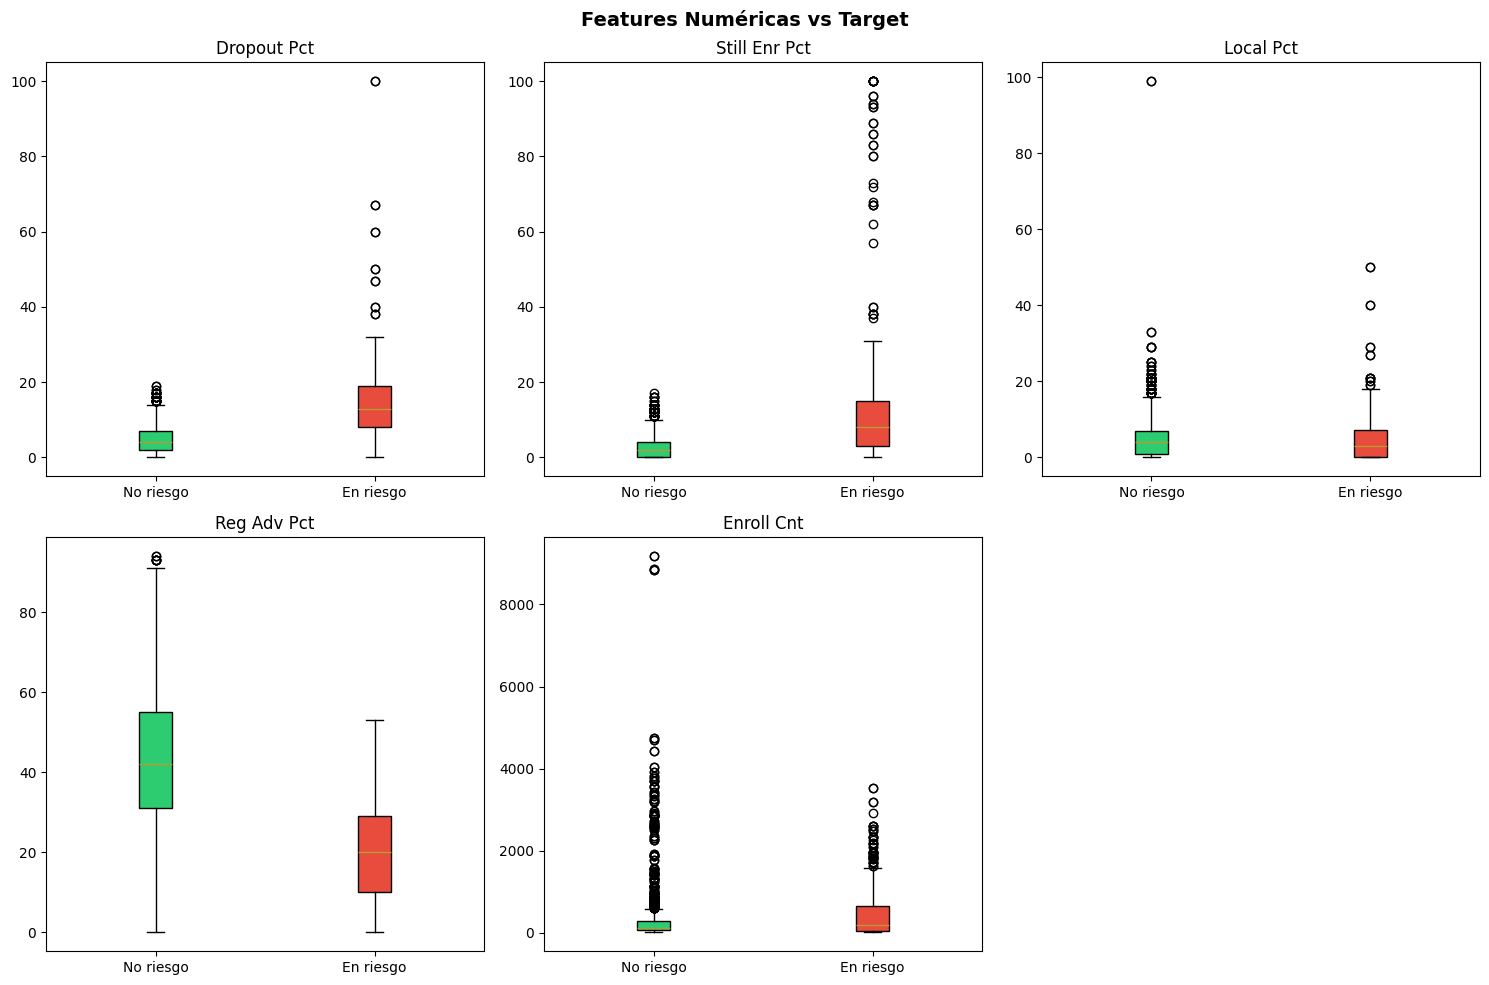

In [14]:
features_num = ['dropout_pct_clean', 'still_enr_pct_clean', 'local_pct_clean', 'reg_adv_pct_clean', 'enroll_cnt']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(features_num):
    data = [df_clean[df_clean['en_riesgo']==0][col].dropna(), 
            df_clean[df_clean['en_riesgo']==1][col].dropna()]
    bp = axes[i].boxplot(data, patch_artist=True)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    axes[i].set_xticklabels(['No riesgo', 'En riesgo'])
    axes[i].set_title(col.replace('_clean', '').replace('_', ' ').title())

axes[-1].axis('off')
plt.suptitle('Features Numéricas vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Features Categóricas vs Target


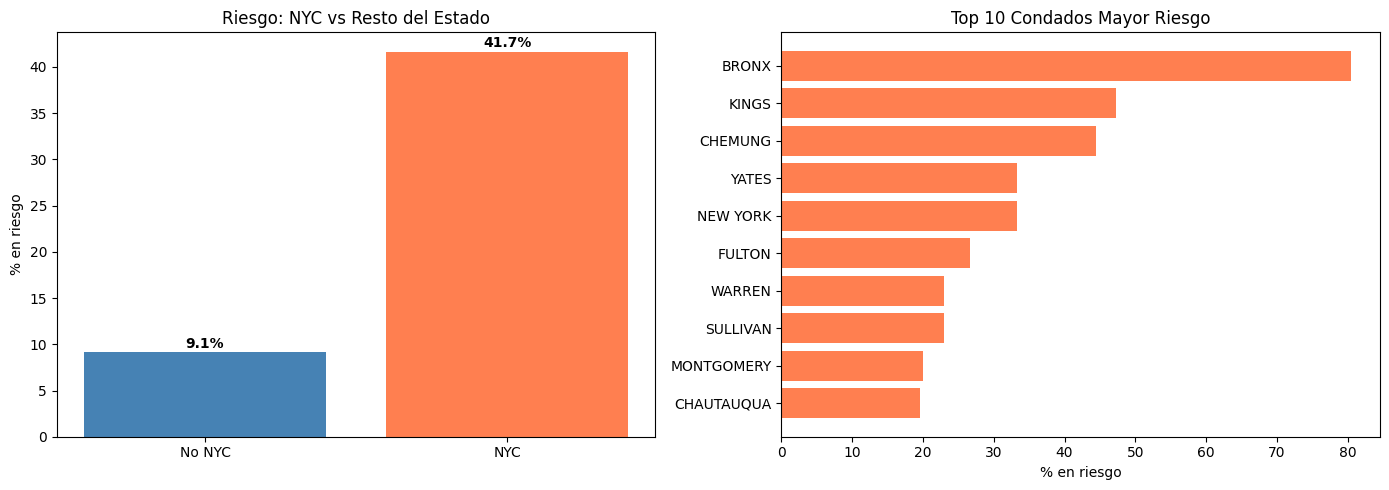

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# NYC vs No NYC
nyc_risk = df_clean.groupby('nyc_ind')['en_riesgo'].mean() * 100
axes[0].bar(['No NYC', 'NYC'], nyc_risk.values, color=['steelblue', 'coral'])
axes[0].set_ylabel('% en riesgo')
axes[0].set_title('Riesgo: NYC vs Resto del Estado')
for i, v in enumerate(nyc_risk.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Top condados con más riesgo
county_risk = df_clean.groupby('county_name')['en_riesgo'].agg(['mean', 'count'])
county_risk = county_risk[county_risk['count'] >= 5].sort_values('mean', ascending=True).tail(10)
axes[1].barh(range(len(county_risk)), county_risk['mean'] * 100, color='coral')
axes[1].set_yticks(range(len(county_risk)))
axes[1].set_yticklabels(county_risk.index)
axes[1].set_xlabel('% en riesgo')
axes[1].set_title('Top 10 Condados Mayor Riesgo')

plt.tight_layout()
plt.show()


## 10. Análisis de Sesgos por Subgrupo Demográfico


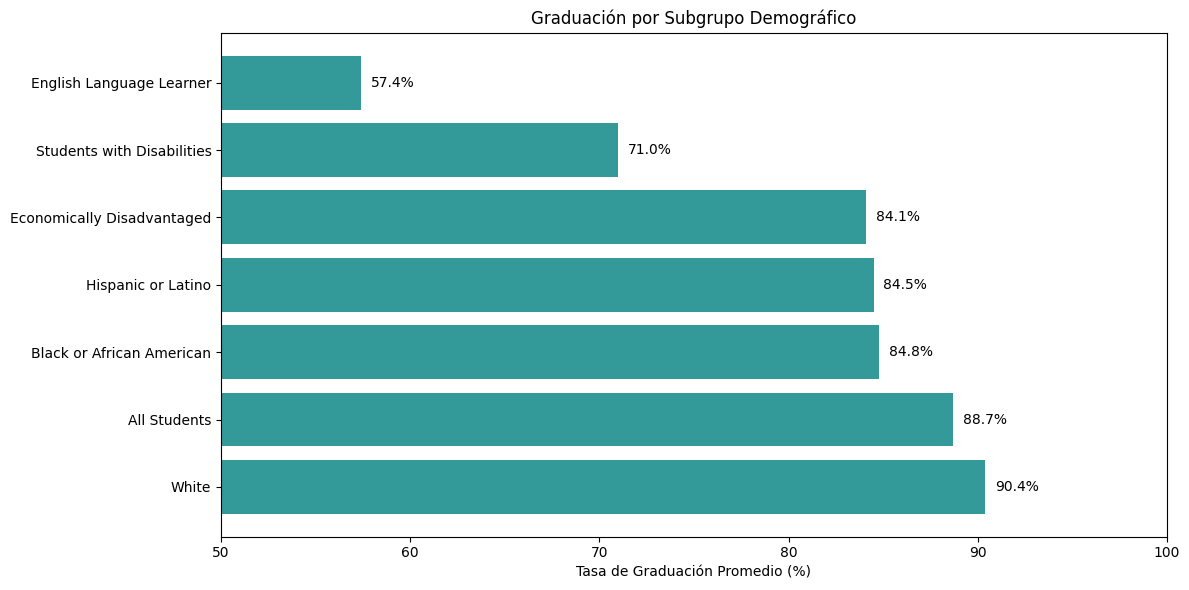

,mean,std,count
subgroup_name,,,
White,90.4,9.9,3024
All Students,88.7,11.4,4040
Black or African American,84.8,12.9,1384
Hispanic or Latino,84.5,12.1,1936
Economically Disadvantaged,84.1,11.5,3920
Students with Disabilities,71.0,15.6,3660
English Language Learner,57.4,18.6,958


In [16]:
df_subgroups = df[df['aggregation_type'] == 'District'].copy()

grupos = ['All Students', 'White', 'Black or African American', 'Hispanic or Latino', 
          'Economically Disadvantaged', 'Students with Disabilities', 'English Language Learner']

sesgo_data = df_subgroups[df_subgroups['subgroup_name'].isin(grupos)]
sesgo_stats = sesgo_data.groupby('subgroup_name')['grad_pct_clean'].agg(['mean', 'std', 'count']).round(1)
sesgo_stats = sesgo_stats.sort_values('mean', ascending=False)

plt.figure(figsize=(12, 6))
plt.barh(range(len(sesgo_stats)), sesgo_stats['mean'].values, color='teal', alpha=0.8)
plt.yticks(range(len(sesgo_stats)), sesgo_stats.index)
plt.xlabel('Tasa de Graduación Promedio (%)')
plt.title('Graduación por Subgrupo Demográfico')
plt.xlim(50, 100)

for i, v in enumerate(sesgo_stats['mean'].values):
    plt.text(v + 0.5, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.show()

sesgo_stats


## 11. Resumen y Conclusiones


In [17]:
resumen = pd.DataFrame({
    'Métrica': [
        'Total registros originales',
        'Registros después de limpieza',
        'Columnas',
        'Distritos únicos',
        'Tasa graduación promedio',
        'Distritos en riesgo (<80%)',
        'Outliers detectados (IQR)'
    ],
    'Valor': [
        f"{len(df):,}",
        f"{len(df_clean):,}",
        df.shape[1],
        df_clean['lea_name'].nunique(),
        f"{df_clean['grad_pct_clean'].mean():.1f}%",
        f"{df_clean['en_riesgo'].sum()} ({df_clean['en_riesgo'].mean()*100:.1f}%)",
        f"{len(outliers)} ({len(outliers)/len(df_clean)*100:.1f}%)"
    ]
})
resumen


,Métrica,Valor
0,Total registros originales,"220,304"
1,Registros después de limpieza,"4,040"
2,Columnas,41
3,Distritos únicos,0
4,Tasa graduación promedio,88.7%
5,Distritos en riesgo (<80%),432 (10.7%)
6,Outliers detectados (IQR),163 (4.0%)


### Hallazgos principales:

1. **Distribución sesgada:** La mayoría de distritos tienen tasas altas (>85%), con una cola hacia valores bajos
2. **Outliers:** ~4% de distritos tienen graduación anormalmente baja (<72.5%)
3. **Correlaciones clave:**
   - `dropout_pct` correlaciona positivamente con riesgo
   - `reg_adv_pct` correlaciona negativamente (más diplomas avanzados = menos riesgo)
4. **Sesgos demográficos:** Estudiantes con discapacidades y ELL tienen tasas significativamente menores

### Features seleccionadas para el modelo:

| Feature | Tipo | Justificación |
|---------|------|---------------|
| `dropout_pct` | Numérica | Alta correlación con riesgo |
| `still_enr_pct` | Numérica | Indica estudiantes "estancados" |
| `local_pct` | Numérica | Tipo de diploma |
| `reg_adv_pct` | Numérica | Correlación negativa con riesgo |
| `enroll_cnt` | Numérica | Tamaño del distrito |
| `nyc_ind` | Categórica | Diferencias NYC vs resto |
| `county_name` | Categórica | Variación geográfica |
| `nrc_desc` | Categórica | Tipo de necesidad/recursos |

